In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\ayush kumar gupta\OneDrive\Desktop\ifood_df.csv")

In [3]:
df.shape

(2205, 39)

In [4]:
df.head(10)

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0
5,62513.0,0,1,16,520,42,98,0,42,14,...,1,0,0,0,0,1,0,702,688,0
6,55635.0,0,1,34,235,65,164,50,49,27,...,0,0,0,0,1,0,0,563,536,0
7,33454.0,1,0,32,76,10,56,3,1,23,...,0,0,0,0,0,0,1,146,123,0
8,30351.0,1,0,19,14,0,24,3,3,2,...,1,0,0,0,0,0,1,44,42,0
9,5648.0,1,1,68,28,0,6,1,1,13,...,1,0,0,0,0,0,1,36,23,1


In [5]:
#checking columns name
df.columns.tolist()

['Income',
 'Kidhome',
 'Teenhome',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Response',
 'Age',
 'Customer_Days',
 'marital_Divorced',
 'marital_Married',
 'marital_Single',
 'marital_Together',
 'marital_Widow',
 'education_2n Cycle',
 'education_Basic',
 'education_Graduation',
 'education_Master',
 'education_PhD',
 'MntTotal',
 'MntRegularProds',
 'AcceptedCmpOverall']

In [6]:
#lets observe all columnms
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [7]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [10]:
#data i found
# this dataset is from an ecommerce company
# it has customer purchase history, demographics
# and marketing campaign response data
# i will use this to group customers into segments

print("total customers:", df.shape[0])
print("total columnms:", df.shape[1])

print("spending columns in dataset:")
spending_colm = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
print(spending_colm)

print("purchase channel columns:")
print(['NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumDealsPurchases'])

total customers: 2205
total columnms: 39
spending columns in dataset:
['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
purchase channel columns:
['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']


In [55]:
# not sure what Z_CostContact and Z_Revenue mean
# i will skip these columns for now
# they seem like internal company columns
print(df[['Z_CostContact', 'Z_Revenue']].value_counts())

Z_CostContact  Z_Revenue
3              11           2021
Name: count, dtype: int64


In [12]:
#checking missing columns
df.isnull().sum()

Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Customer_Days           0
marital_Divorced        0
marital_Married         0
marital_Single          0
marital_Together        0
marital_Widow           0
education_2n Cycle      0
education_Basic         0
education_Graduation    0
education_Master        0
education_PhD           0
MntTotal                0
MntRegularProds         0
AcceptedCmpO

In [14]:
# checking duplicates
df.duplicated().sum()

np.int64(184)

In [16]:
# basic stats of important columns
print("income stats:")
print(df['Income'].describe())
print()
print("age stats:")
print(df['Age'].describe())
print()
print("total spending stats:")
print(df['MntTotal'].describe())

income stats:
count      2205.000000
mean      51622.094785
std       20713.063826
min        1730.000000
25%       35196.000000
50%       51287.000000
75%       68281.000000
max      113734.000000
Name: Income, dtype: float64

age stats:
count    2205.000000
mean       51.095692
std        11.705801
min        24.000000
25%        43.000000
50%        50.000000
75%        61.000000
max        80.000000
Name: Age, dtype: float64

total spending stats:
count    2205.000000
mean      562.764626
std       575.936911
min         4.000000
25%        56.000000
50%       343.000000
75%       964.000000
max      2491.000000
Name: MntTotal, dtype: float64


In [17]:
# checking how many kids and teens customers have
print("kids at home:")
print(df['Kidhome'].value_counts())
print()
print("teens at home:")
print(df['Teenhome'].value_counts())

kids at home:
Kidhome
0    1276
1     883
2      46
Name: count, dtype: int64

teens at home:
Teenhome
0    1139
1    1015
2      51
Name: count, dtype: int64


In [18]:
# checking campaign acceptance
print("overall campaign acceptance:")
print(df['AcceptedCmpOverall'].value_counts())

overall campaign acceptance:
AcceptedCmpOverall
0    1747
1     322
2      81
3      44
4      11
Name: count, dtype: int64


In [19]:
# no missing values found but still doing basic cleaning
# removing duplicates just to be safe

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)


In [20]:
# checking for unrealistic ages
print("max age:", df['Age'].max())
print("min age:", df['Age'].min())

# removing if any age is above 90
df = df[df['Age'] <= 90]
df.reset_index(drop=True, inplace=True)
print("shape after age filter:", df.shape)

max age: 80
min age: 24
shape after age filter: (2021, 39)


In [21]:
# checking for negative income or spending
print("negative income rows:", (df['Income'] < 0).sum())
print("negative spending rows:", (df['MntTotal'] < 0).sum())

negative income rows: 0
negative spending rows: 0


In [22]:
# creating total purchases column
df['Total_Purchases'] = (df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases'])

print("total purchases column created")
print("average purchases:", round(df['Total_Purchases'].mean(), 2))

total purchases column created
average purchases: 12.57


In [23]:
# final shape after cleaning
print("final dataset shape:", df.shape)
#check if any null value
print("any missing values:", df.isnull().sum().sum())

final dataset shape: (2021, 40)
any missing values: 0


In [26]:
#now we find key matrics

print("avg income per customer:",
      round(df['Income'].mean(), 2))
print("avg age of customers:",
      round(df['Age'].mean(), 2))
print("avg total spending:",
      round(df['MntTotal'].mean(), 2))
print("avg total purchases:",
      round(df['Total_Purchases'].mean(), 2))
print("avg recency (days since last purchase):",
      round(df['Recency'].mean(), 2))
print("avg customer days (how long they are customer):",
      round(df['Customer_Days'].mean(), 2))

avg income per customer: 51687.26
avg age of customers: 51.12
avg total spending: 563.79
avg total purchases: 12.57
avg recency (days since last purchase): 48.88
avg customer days (how long they are customer): 2511.61


In [27]:
# spending per product category
print("average spending per product category:")
for col in spend_cols:
    print(f"  {col}: {round(df[col].mean(), 2)}")

average spending per product category:
  MntWines: 306.49
  MntFruits: 26.36
  MntMeatProducts: 166.06
  MntFishProducts: 37.6
  MntSweetProducts: 27.27
  MntGoldProds: 43.92


In [28]:
# frequency of purchases by channel
print("average purchases by channel:")
print("  web:", round(df['NumWebPurchases'].mean(), 2))
print("  catalog:", round(df['NumCatalogPurchases'].mean(), 2))
print("  store:", round(df['NumStorePurchases'].mean(), 2))
print("  deals:", round(df['NumDealsPurchases'].mean(), 2))

average purchases by channel:
  web: 4.12
  catalog: 2.64
  store: 5.81
  deals: 2.33


In [29]:
# campaign response stats
print("campaign acceptance rates:")
print("  campaign 1:", round(df['AcceptedCmp1'].mean() * 100, 2), "%")
print("  campaign 2:", round(df['AcceptedCmp2'].mean() * 100, 2), "%")
print("  campaign 3:", round(df['AcceptedCmp3'].mean() * 100, 2), "%")
print("  campaign 4:", round(df['AcceptedCmp4'].mean() * 100, 2), "%")
print("  campaign 5:", round(df['AcceptedCmp5'].mean() * 100, 2), "%")

campaign acceptance rates:
  campaign 1: 6.58 %
  campaign 2: 1.29 %
  campaign 3: 7.47 %
  campaign 4: 7.67 %
  campaign 5: 7.22 %


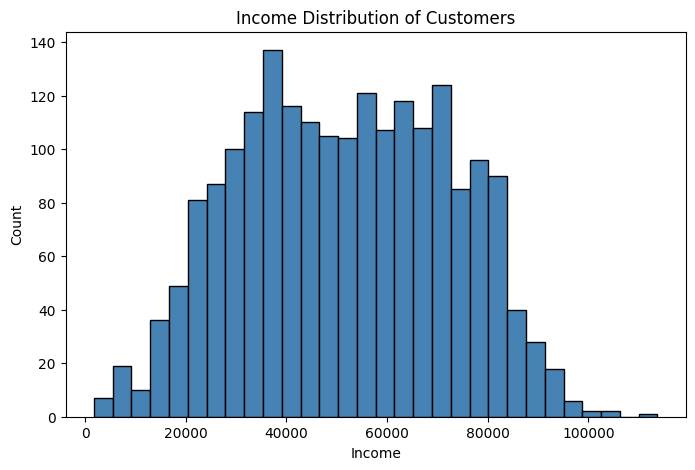

In [31]:
#lets start visualize what i found
# income distribution
plt.figure(figsize=(8, 5))
plt.hist(df['Income'], bins=30, color='steelblue', edgecolor='black')
plt.title('Income Distribution of Customers')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()


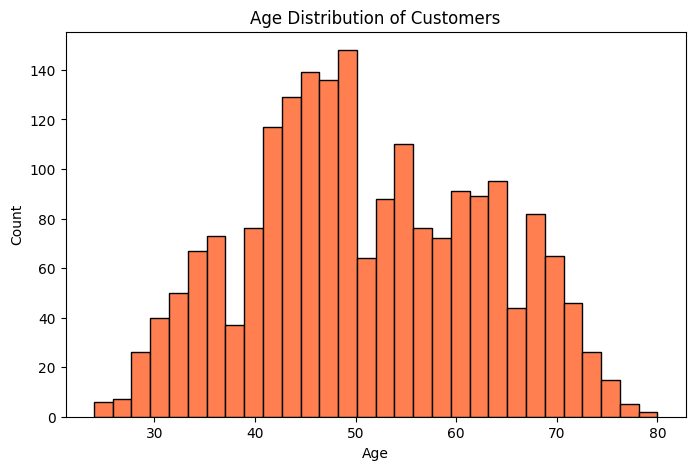

In [32]:
# age distribution
plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=30, color='coral', edgecolor='black')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

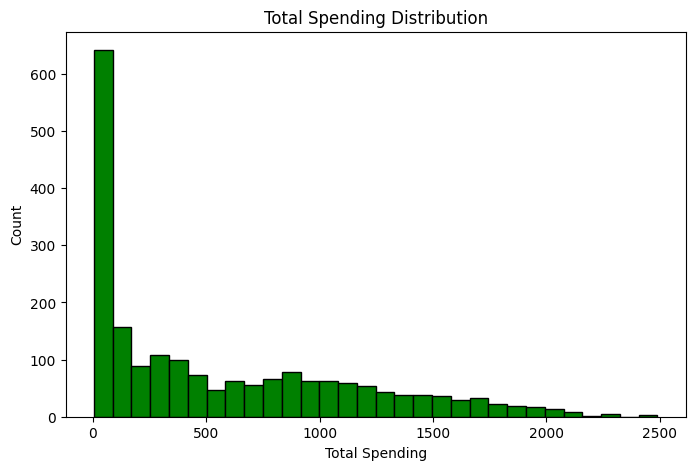

In [33]:
# total spending distribution
plt.figure(figsize=(8, 5))
plt.hist(df['MntTotal'], bins=30, color='green', edgecolor='black')
plt.title('Total Spending Distribution')
plt.xlabel('Total Spending')
plt.ylabel('Count')
plt.show()

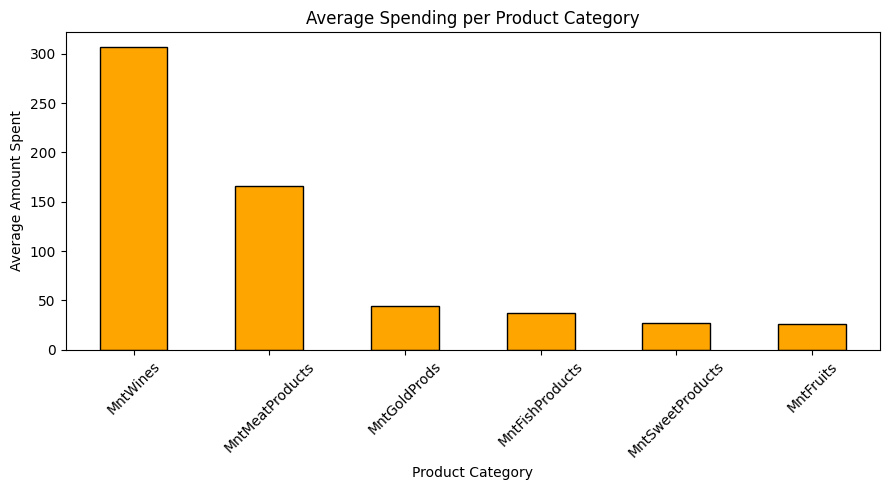

In [34]:
# average spending per category
avg_spend = df[spend_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
avg_spend.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Average Spending per Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Amount Spent')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

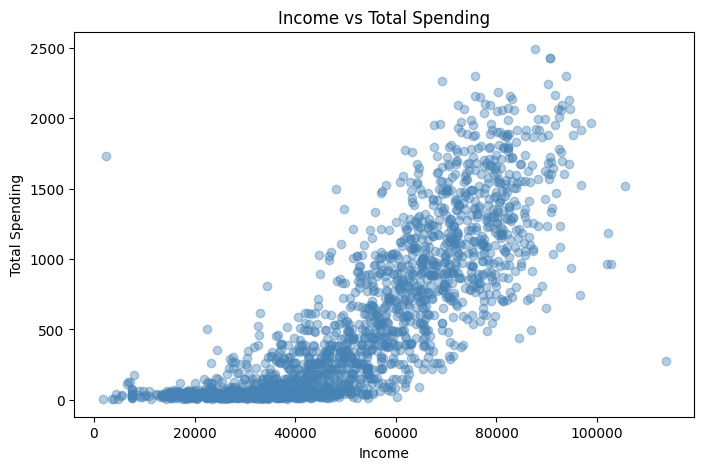

In [35]:
# income vs total spending scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df['Income'], df['MntTotal'], alpha=0.4, color='steelblue')
plt.title('Income vs Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.show()


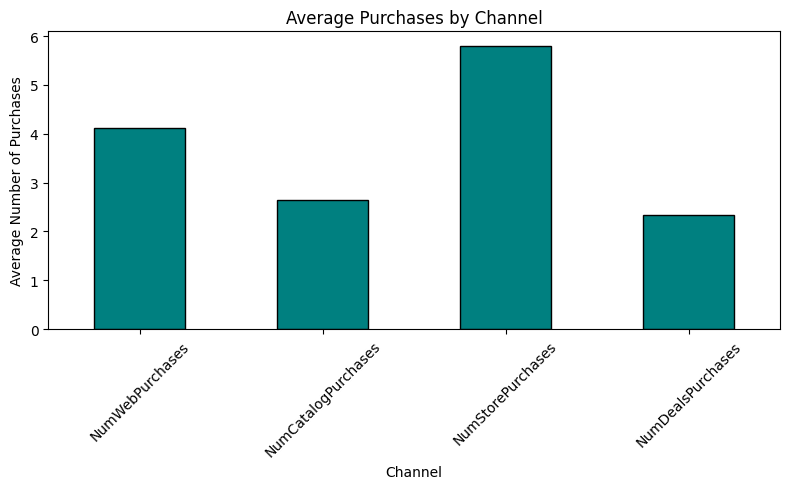

In [36]:
# purchases by channel bar chart
channel_avg = df[['NumWebPurchases', 'NumCatalogPurchases','NumStorePurchases', 'NumDealsPurchases']].mean()

plt.figure(figsize=(8, 5))
channel_avg.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Average Purchases by Channel')
plt.xlabel('Channel')
plt.ylabel('Average Number of Purchases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

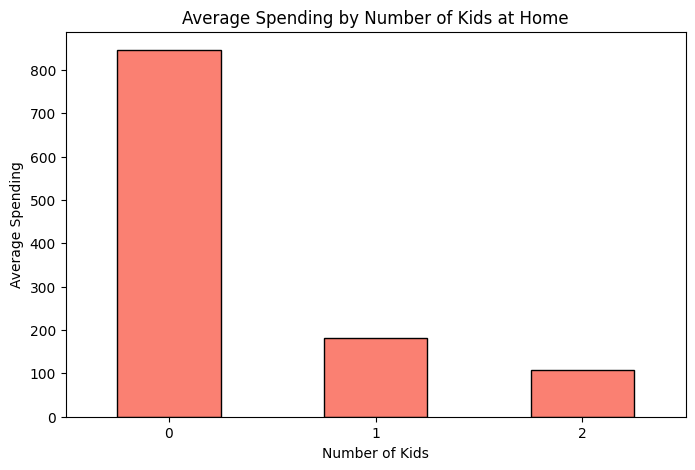

In [37]:
# kids and teens vs spending
plt.figure(figsize=(8, 5))
df.groupby('Kidhome')['MntTotal'].mean().plot(
    kind='bar', color='salmon', edgecolor='black')
plt.title('Average Spending by Number of Kids at Home')
plt.xlabel('Number of Kids')
plt.ylabel('Average Spending')
plt.xticks(rotation=0)
plt.show()


In [38]:
# selecting features for clustering
# income, total spending and age represent customer
# behavior and demographics well
features = df[['Income', 'MntTotal', 'Age']]

print("features selected for clustering:")
print(features.describe())

features selected for clustering:
              Income     MntTotal          Age
count    2021.000000  2021.000000  2021.000000
mean    51687.258783   563.789213    51.117269
std     20713.046401   576.775749    11.667616
min      1730.000000     4.000000    24.000000
25%     35416.000000    55.000000    43.000000
50%     51412.000000   343.000000    50.000000
75%     68274.000000   964.000000    61.000000
max    113734.000000  2491.000000    80.000000


In [39]:
# scaling features
# very important step because income is in lakhs
# while age is just 20 to 90
# without scaling income will dominate clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

print("scaling done")
print("shape:", scaled_data.shape)

scaling done
shape: (2021, 3)


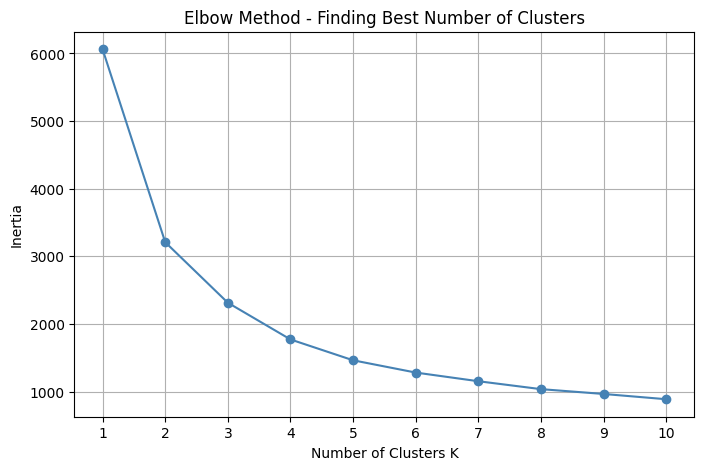

In [40]:
# finding best k using elbow method
inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o', color='steelblue')
plt.title('Elbow Method - Finding Best Number of Clusters')
plt.xlabel('Number of Clusters K')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

# the curve bends around k=4 so i will use 4 clusters

In [ ]:
# plotting elbow curve to find best k
# i tried different values and 4 seemed right from the graph
# the line stops going down sharply after 4

In [41]:
# applying kmeans with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

print("clustering done!")
print()
print("customers in each cluster:")
print(df['Cluster'].value_counts().sort_index())

clustering done!

customers in each cluster:
Cluster
0    512
1    406
2    382
3    721
Name: count, dtype: int64


In [42]:
# cluster wise average values
print("cluster summary:")
summary = df.groupby('Cluster')[['Income', 'MntTotal',
                                  'Age', 'Total_Purchases',
                                  'Recency']].mean()
print(summary.round(2))

cluster summary:
           Income  MntTotal    Age  Total_Purchases  Recency
Cluster                                                     
0        45865.39    240.00  60.83             9.84    49.82
1        72736.05   1194.31  42.80            19.50    48.98
2        72027.10   1168.48  63.43            19.66    48.85
3        33192.35    118.29  42.38             6.84    48.18


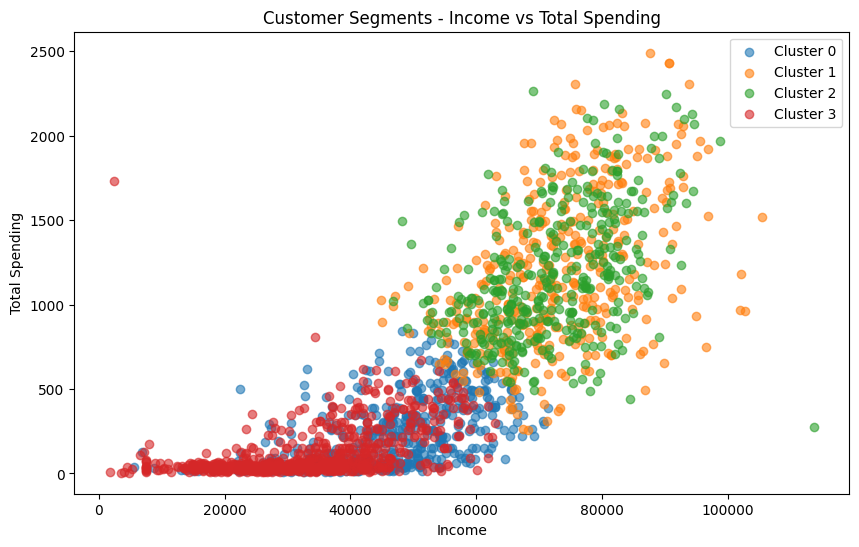

In [43]:
# income vs spending scatter plot by cluster
plt.figure(figsize=(10, 6))
for cluster in range(4):
    c = df[df['Cluster'] == cluster]
    plt.scatter(c['Income'], c['MntTotal'],
                label=f'Cluster {cluster}', alpha=0.6)

plt.title('Customer Segments - Income vs Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.legend()
plt.show()

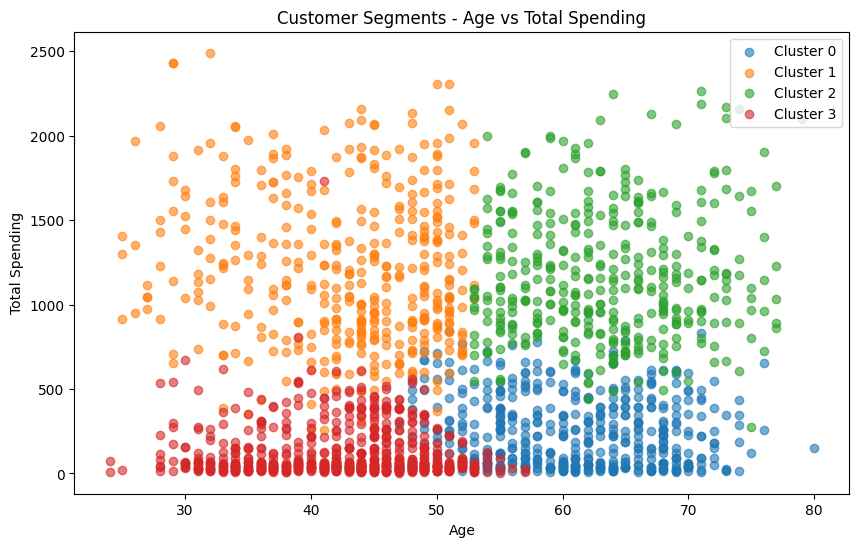

In [44]:
# age vs spending scatter plot by cluster
plt.figure(figsize=(10, 6))
for cluster in range(4):
    c = df[df['Cluster'] == cluster]
    plt.scatter(c['Age'], c['MntTotal'],
                label=f'Cluster {cluster}', alpha=0.6)

plt.title('Customer Segments - Age vs Total Spending')
plt.xlabel('Age')
plt.ylabel('Total Spending')
plt.legend()
plt.show()

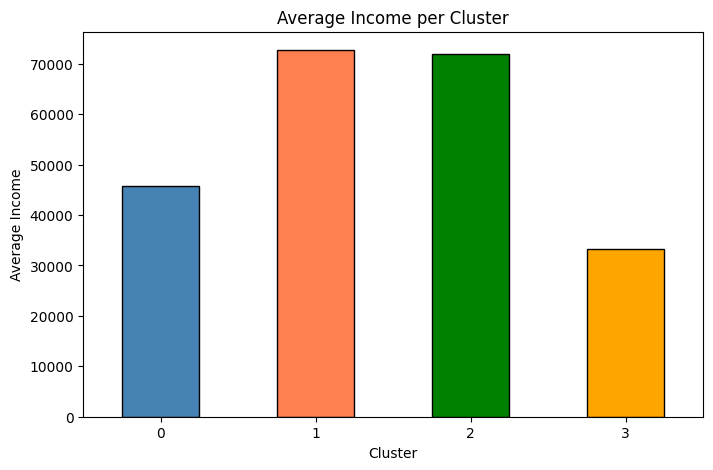

In [45]:
# average income per cluster bar chart
df.groupby('Cluster')['Income'].mean().plot(
    kind='bar',
    color=['steelblue', 'coral', 'green', 'orange'],
    edgecolor='black',
    figsize=(8, 5))
plt.title('Average Income per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Income')
plt.xticks(rotation=0)
plt.show()

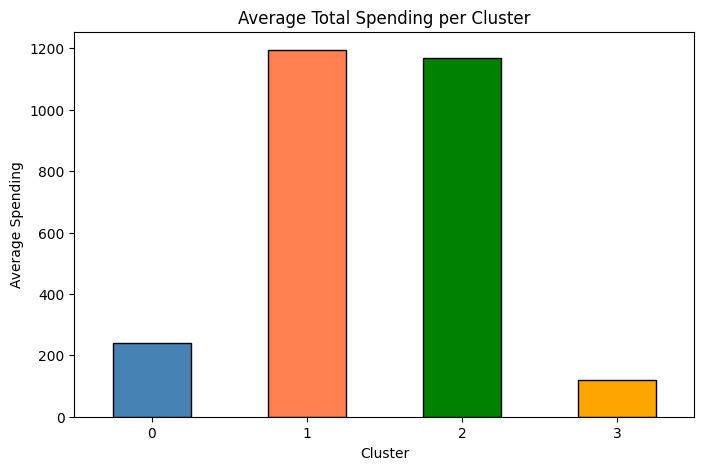

In [46]:
# average total spending per cluster
df.groupby('Cluster')['MntTotal'].mean().plot(
    kind='bar',
    color=['steelblue', 'coral', 'green', 'orange'],
    edgecolor='black',
    figsize=(8, 5))
plt.title('Average Total Spending per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Spending')
plt.xticks(rotation=0)
plt.show()

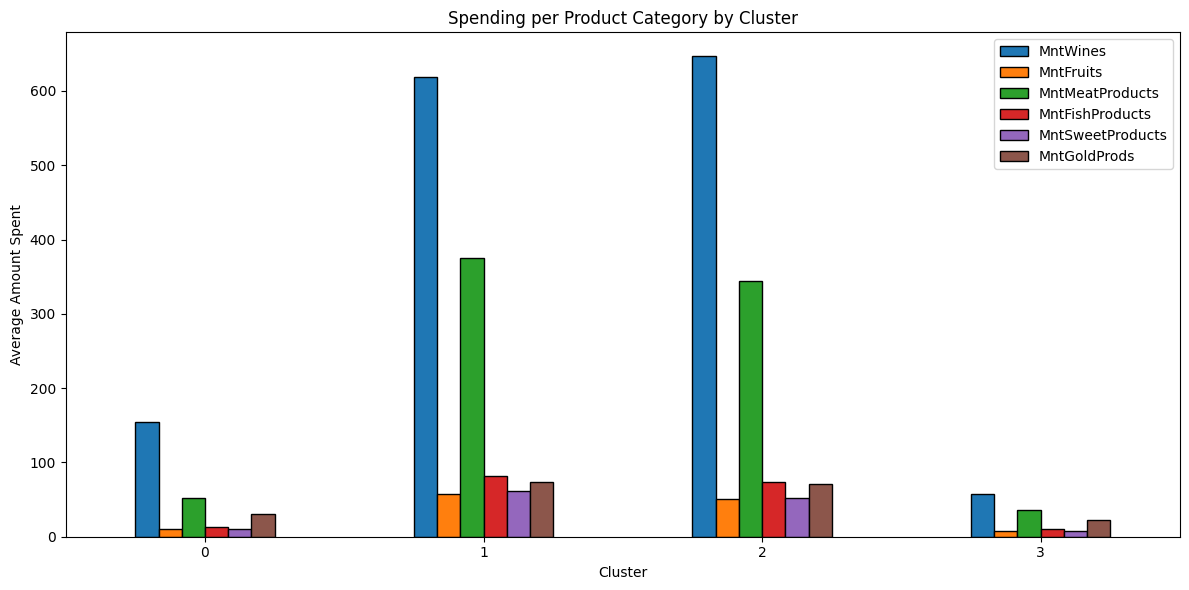

In [47]:
# product category spending by cluster
spend_by_cluster = df.groupby('Cluster')[spend_cols].mean()

spend_by_cluster.plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.title('Spending per Product Category by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Amount Spent')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

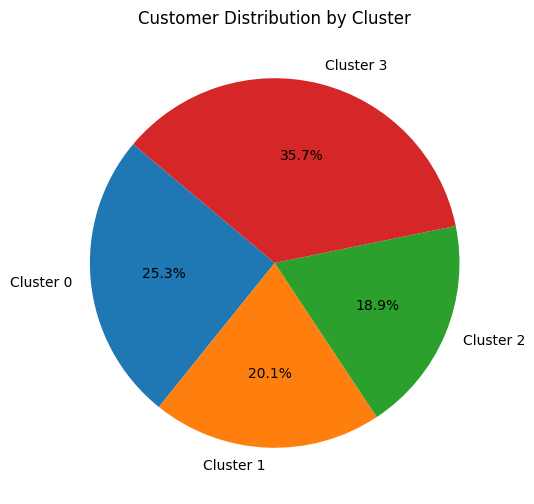

In [48]:
# pie chart customer count per cluster
cluster_counts = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(6, 6))
plt.pie(cluster_counts.values,
        labels=[f'Cluster {i}' for i in cluster_counts.index],
        autopct='%1.1f%%', startangle=140)
plt.title('Customer Distribution by Cluster')
plt.show()

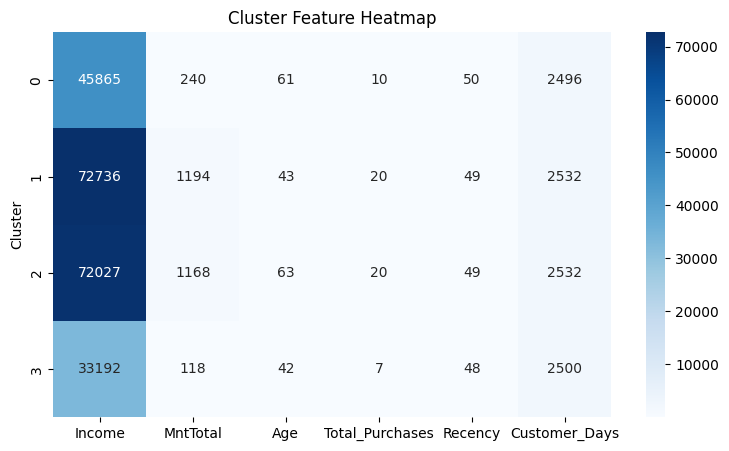

In [50]:
# heatmap
plt.figure(figsize=(9, 5))
heatmap_data = df.groupby('Cluster')[['Income', 'MntTotal', 'Age', 'Total_Purchases','Recency', 'Customer_Days']].mean()
                                    
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='Blues')
plt.title('Cluster Feature Heatmap')
plt.show()

In [51]:
#cluster analysis


for cluster in range(4):
    data = df[df['Cluster'] == cluster]
    print(f"cluster {cluster}:")
    print(f"  total customers  : {len(data)}")
    print(f"  avg income       : {round(data['Income'].mean(), 2)}")
    print(f"  avg spending     : {round(data['MntTotal'].mean(), 2)}")
    print(f"  avg age          : {round(data['Age'].mean(), 2)}")
    print(f"  avg purchases    : {round(data['Total_Purchases'].mean(), 2)}")
    print(f"  avg recency      : {round(data['Recency'].mean(), 2)} days")
    print(f"  avg customer days: {round(data['Customer_Days'].mean(), 2)}")
    print()

cluster 0:
  total customers  : 512
  avg income       : 45865.39
  avg spending     : 240.0
  avg age          : 60.83
  avg purchases    : 9.84
  avg recency      : 49.82 days
  avg customer days: 2495.88

cluster 1:
  total customers  : 406
  avg income       : 72736.05
  avg spending     : 1194.31
  avg age          : 42.8
  avg purchases    : 19.5
  avg recency      : 48.98 days
  avg customer days: 2532.49

cluster 2:
  total customers  : 382
  avg income       : 72027.1
  avg spending     : 1168.48
  avg age          : 63.43
  avg purchases    : 19.66
  avg recency      : 48.85 days
  avg customer days: 2531.96

cluster 3:
  total customers  : 721
  avg income       : 33192.35
  avg spending     : 118.29
  avg age          : 42.38
  avg purchases    : 6.84
  avg recency      : 48.18 days
  avg customer days: 2500.25



In [52]:
# what i found from each cluster

# cluster 0 - high income high spending
#   these are the best customers
#   spend most on wines and meat
#   should get premium and loyalty offers

# cluster 1 - low income low spending
#   budget customers
#   respond to discount and deal offers
#   need to be encouraged with cheap bundles

# cluster 2 - medium income moderate spending
#   regular buyers
#   occasional shoppers
#   targeted email promotions can help

# cluster 3 - older customers moderate income
#   have been customers for longer time
#   purchase less frequently
#   re engagement campaigns needed

print("observations written above in comments")

observations written above in comments


In [53]:
print("  recommendations \n")
print("1. high value customers:")
print("   send them premium product offers")
print("   give early access to new products")
print("   wines and meat promotions work best")
print()
print("2. budget customers:")
print("   give discount coupons and combo deals")
print("   free shipping on minimum order")
print("   weekly sale alerts")
print()
print("3. regular customers:")
print("   send seasonal offers")
print("   referral bonus programs")
print("   remind them about items they bought before")
print()
print("4. inactive customers:")
print("   send re engagement emails")
print("   special comeback discount")
print("   show them what is new since last visit")

  recommendations 

1. high value customers:
   send them premium product offers
   give early access to new products
   wines and meat promotions work best

2. budget customers:
   give discount coupons and combo deals
   free shipping on minimum order
   weekly sale alerts

3. regular customers:
   send seasonal offers
   referral bonus programs
   remind them about items they bought before

4. inactive customers:
   send re engagement emails
   special comeback discount
   show them what is new since last visit


In [54]:
df.to_csv('ifood_segmented.csv', index=False)

In [56]:
# so basically i found 4 types of customers
# this was my first time using kmeans and it was pretty interesting
# the elbow method part took me some time to understand
# but the results make sense when i look at income vs spending chart

print("project done!")
print("total customers:", len(df))
print("segments found:", df['Cluster'].nunique())

project done!
total customers: 2021
segments found: 4
